# Trabajo Final de Machine Learning - Ejercicio 2
## Clasificacion: contratacion de deposito a plazo

**Grupo:** F
**Integrantes:**
- Alexis Gonzalez
- Luis Morales
- Alexia Orce
- Georgina Sicco
- Emiliano Prockoff

Se predice si un cliente suscribira (`yes`) o no (`no`) un deposito bancario a largo plazo.

## 1. Metadata y planteamiento

El dataset Bank Marketing registra campanas telefonicas de una institucion bancaria. La variable objetivo es `y`. Se utiliza `bank-full.csv`, disponible dentro de `bank.zip`, con separador punto y coma.

Como existe desbalance de clases, se reportan precision, recall, F1, ROC-AUC y matriz de confusion, ademas de accuracy.

## Contexto del rubro: banca y marketing directo

Los bancos ofrecen productos de ahorro e inversion, entre ellos los **depositos a plazo**. En este producto, el cliente deja su dinero durante un periodo acordado y recibe una remuneracion según las condiciones del banco. Para la entidad, estos depósitos ayudan a planificar sus recursos y financiar otras actividades.

El dataset registra una campaña de marketing directo realizada por teléfono. Cada fila representa un cliente contactado y contiene información como edad, ocupación, educación, saldo, préstamos, historial de contactos y resultado de campañas anteriores.

La decisión comercial es priorizar a los clientes con mayor probabilidad de contratar. Esto puede reducir contactos innecesarios y orientar mejor el trabajo del equipo, pero debe hacerse respetando la autonomía del cliente y revisando posibles sesgos en los datos.

Por eso no alcanza con contar aciertos: también es importante distinguir entre contactar a alguien que no estaba interesado y dejar fuera a una persona que sí podía contratar. Las métricas de precision, recall y F1 ayudan a analizar ese equilibrio.

In [1]:
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path('datasets/bank-full.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df['y'].value_counts(normalize=True).rename('proporcion').to_frame())

Dimensiones: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,proporcion
y,
no,0.883015
yes,0.116985


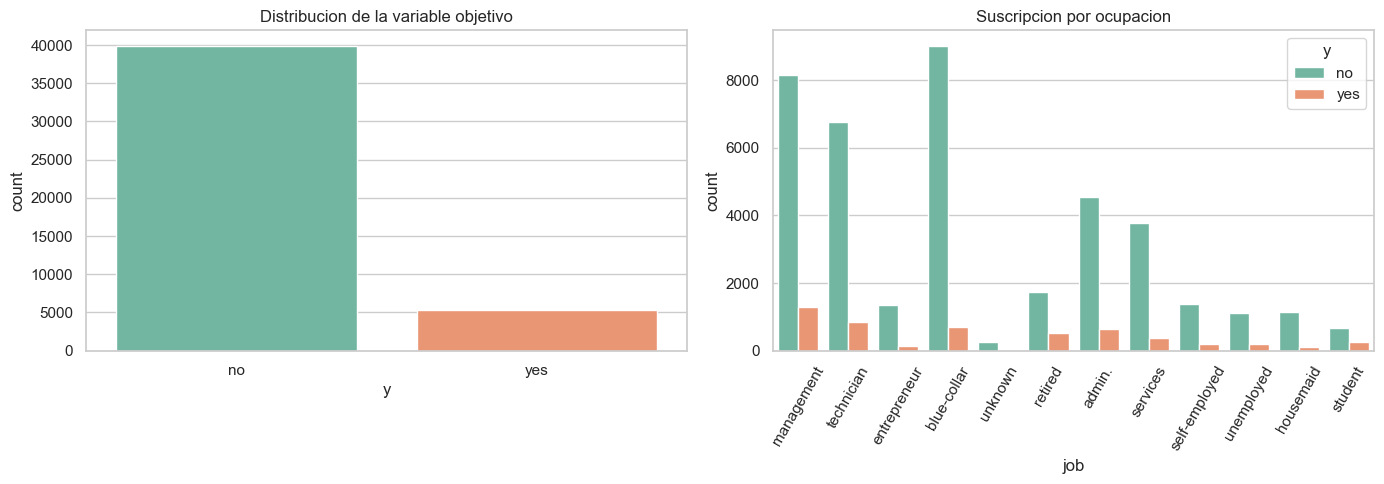

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='y', ax=axes[0], hue='y', legend=False, palette='Set2')
axes[0].set_title('Distribucion de la variable objetivo')
sns.countplot(data=df, x='job', hue='y', ax=axes[1], palette='Set2')
axes[1].set_title('Suscripcion por ocupacion')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()
display(df.describe(include='all').T.head(25))

### Hallazgos de los gráficos

- **Distribución de la variable objetivo:** existe un desbalance fuerte: el 88,30 % de los clientes no contrató el depósito y solo el 11,70 % sí lo hizo. Por eso la accuracy aislada puede resultar engañosa y debe complementarse con precision, recall y F1 de la clase “Sí”.
- **Suscripción por ocupación:** las ocupaciones con más registros generan más suscripciones en términos absolutos, pero este gráfico mezcla volumen y propensión. Para comparar el interés real entre ocupaciones es más apropiado observar la tasa de suscripción presentada en los gráficos posteriores.

## 2. Analisis de las variables predictoras

Las variables predictoras describen al cliente, su situacion financiera y el historial de contacto. Analizamos por separado las variables numericas y categoricas para observar que diferencias aparecen entre quienes contrataron y quienes no.

- Los histogramas comparan la distribucion de las variables numericas según la clase objetivo.
- Los diagramas de barras muestran la tasa de suscripcion dentro de cada categoria.
- La comparacion es descriptiva: una diferencia visual no prueba que una variable sea la causa de la contratacion.

Este analisis ayuda a comprender los datos y a detectar variables que pueden aportar informacion antes de entrenar los modelos.

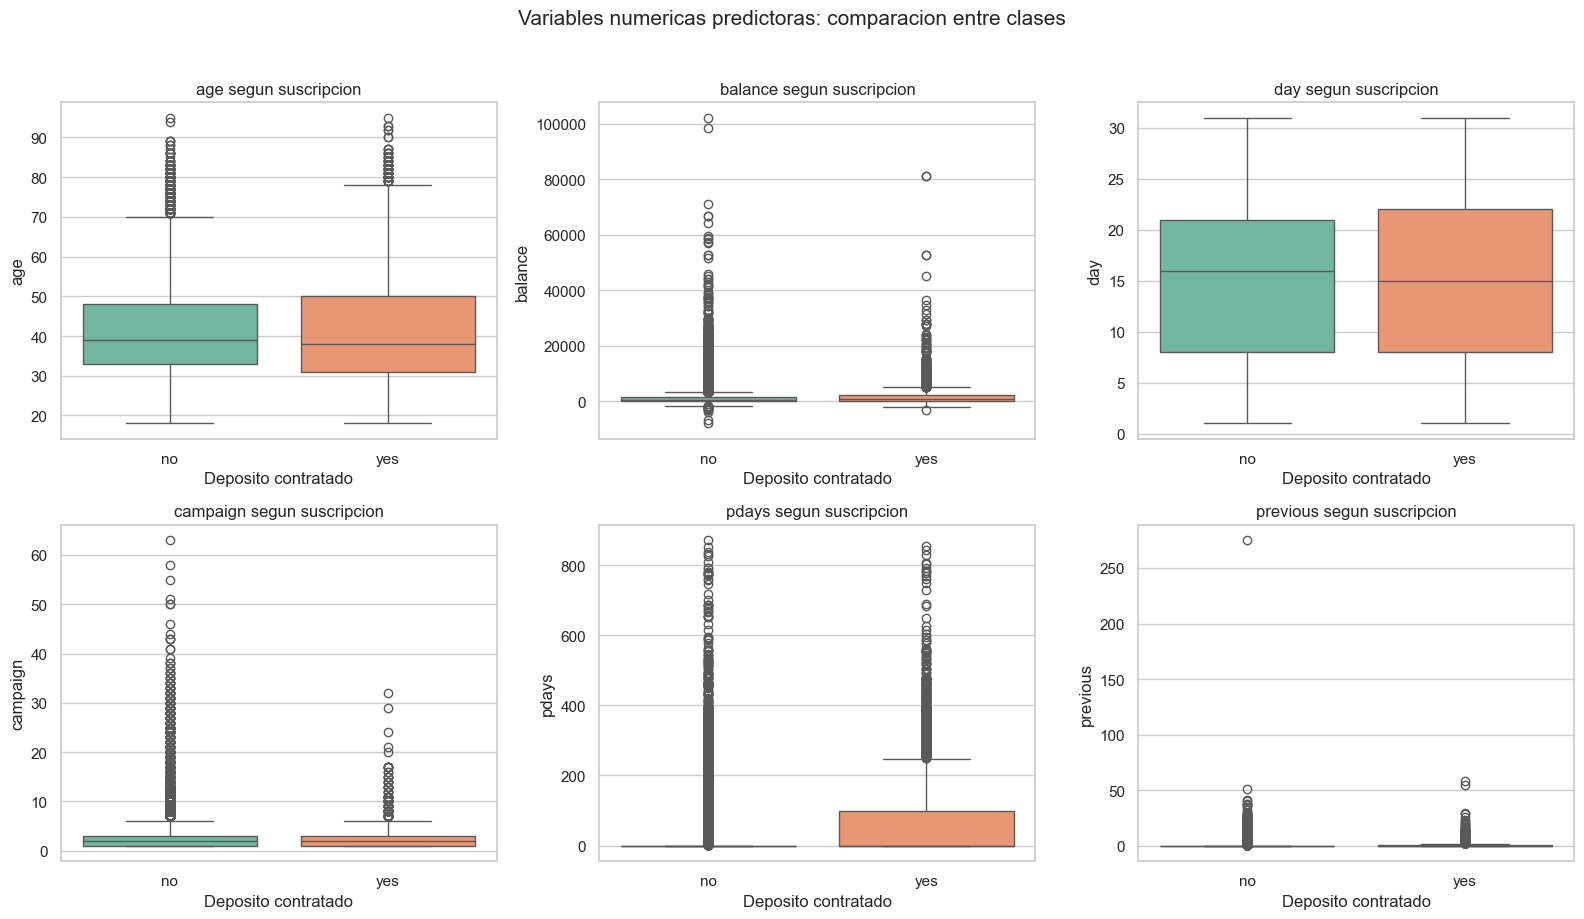

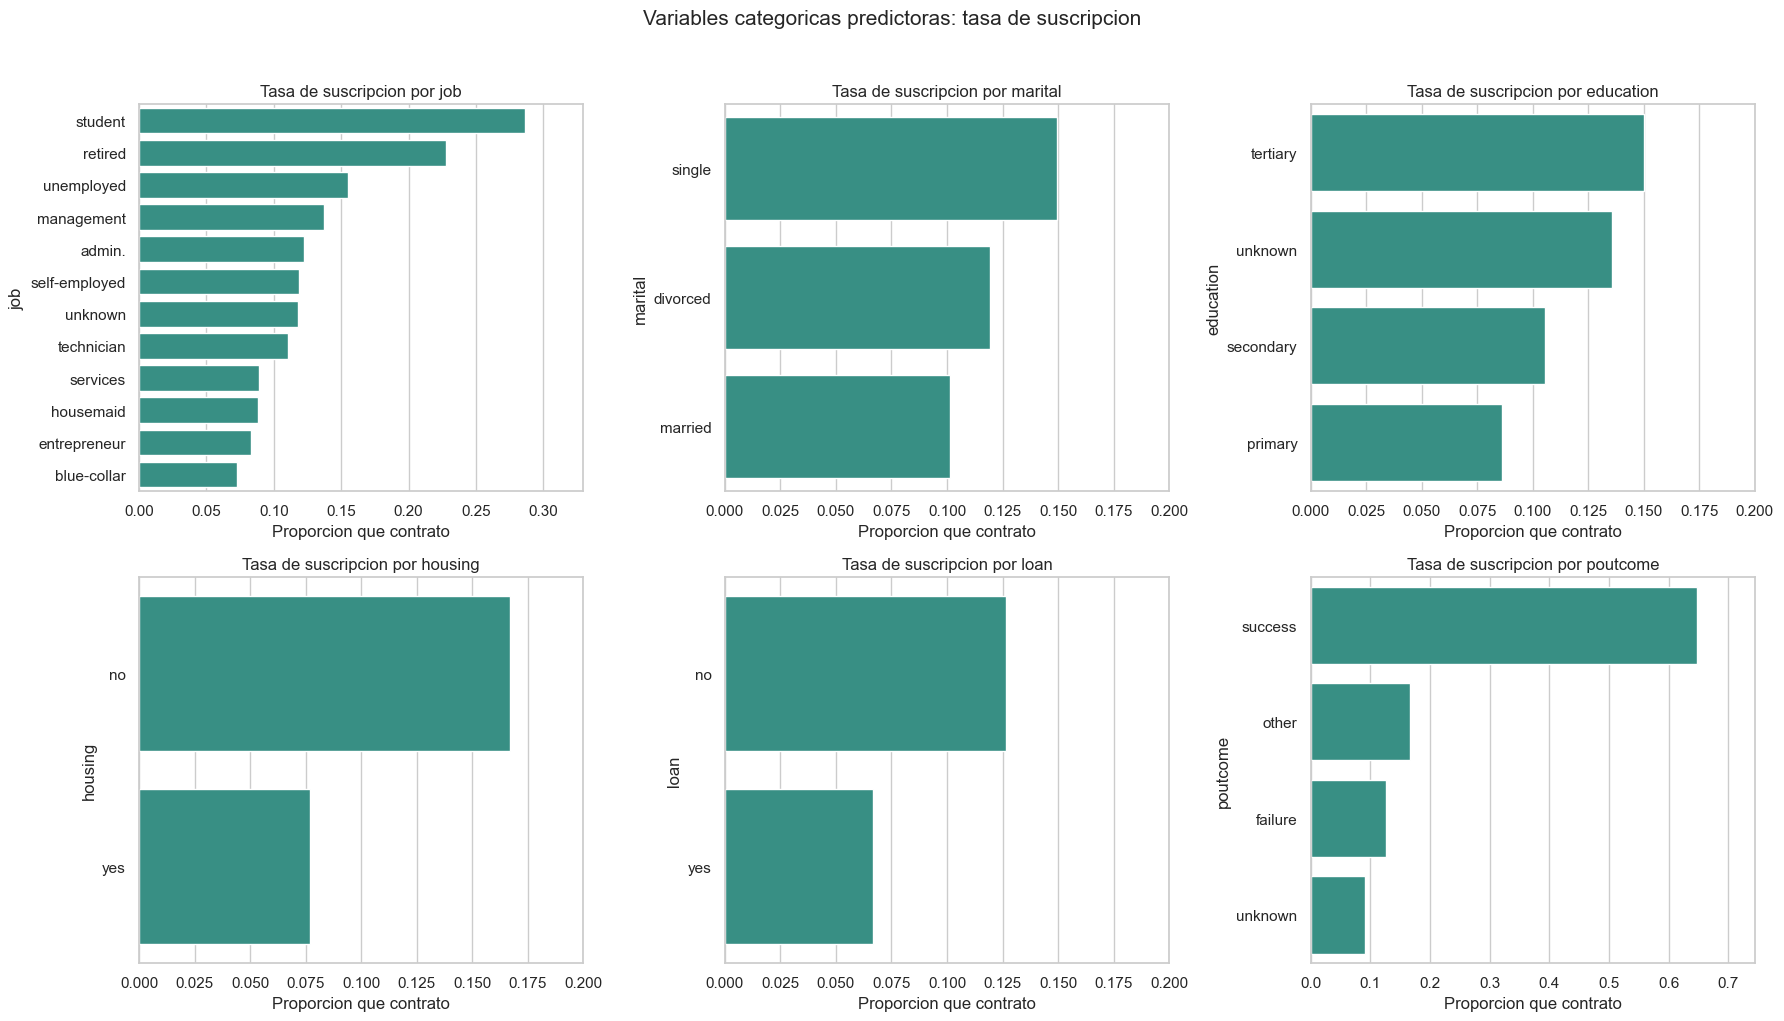

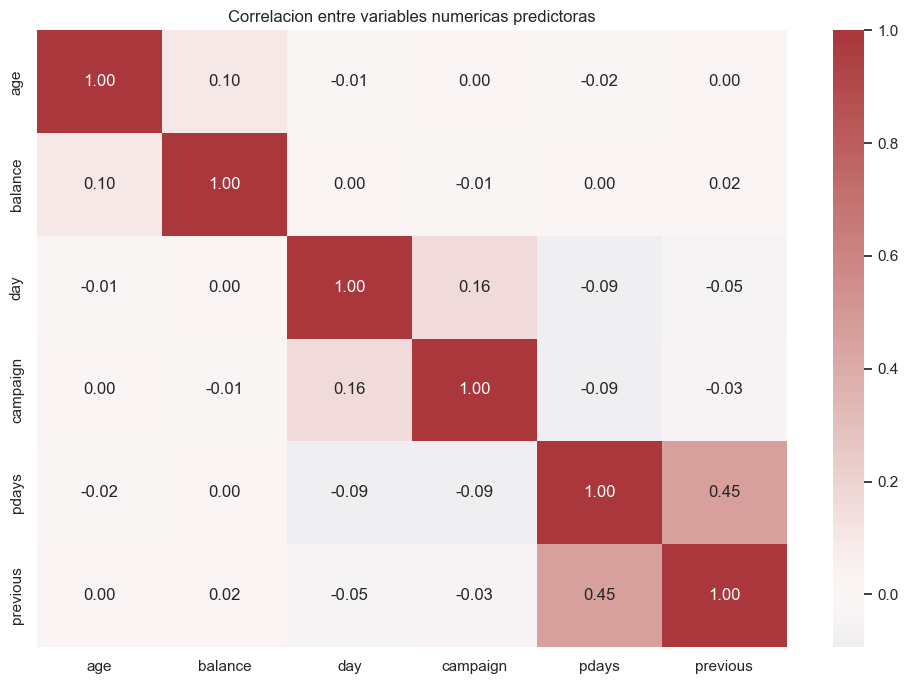

In [4]:
numeric_predictors = [column for column in df.select_dtypes(include=np.number).columns if column not in ['duration']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.ravel(), numeric_predictors):
    sns.boxplot(data=df, x='y', y=column, hue='y', legend=False, ax=ax, palette='Set2')
    ax.set_title(f'{column} segun suscripcion')
    ax.set_xlabel('Deposito contratado')
    ax.set_ylabel(column)
plt.suptitle('Variables numericas predictoras: comparacion entre clases', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

categorical_predictors = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, column in zip(axes.ravel(), categorical_predictors):
    rates = df.groupby(column, observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color='#2a9d8f')
    ax.set_title(f'Tasa de suscripcion por {column}')
    ax.set_xlabel('Proporcion que contrato')
    ax.set_ylabel(column)
    ax.set_xlim(0, max(0.2, rates.max() * 1.15))
plt.suptitle('Variables categoricas predictoras: tasa de suscripcion', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_predictors].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlacion entre variables numericas predictoras')
plt.tight_layout()
plt.show()

### Hallazgos de los gráficos

- **Variables numéricas por clase:** quienes contrataron presentan un saldo central más alto (mediana 733 frente a 417) y fueron contactados menos veces durante la campaña. Edad y día del mes muestran bastante solapamiento; `pdays` y `previous` reflejan que el historial previo puede aportar información, aunque abundan clientes sin contacto anterior.
- **Tasas por variables categóricas:** `poutcome` es el diferenciador más fuerte: un resultado exitoso en una campaña anterior se asocia con una tasa de suscripción claramente superior. También aparecen diferencias por ocupación, educación, vivienda y préstamo, pero son asociaciones descriptivas y pueden estar relacionadas con otras características del cliente.
- **Correlación entre variables numéricas:** no se observan correlaciones lineales extremas entre la mayoría de los predictores. La relación más estructural se da entre `pdays` y `previous`, porque ambas variables describen contactos anteriores; esto no impide que aporten información distinta al modelo.

## 2.1. EDA profundo: calidad, desbalance y comportamiento por clase

Además de observar cada predictor, revisamos la calidad de los registros, la presencia de categorías desconocidas y el desbalance de la variable objetivo. También comparamos tasas de suscripción en combinaciones de variables para detectar patrones que podrían ser útiles para el modelado.

## Estrategia frente al desbalance de clases

El dataset presenta un desbalance importante: aproximadamente el 88,3% de los clientes no contrató el depósito y el 11,7% sí lo hizo. Esto significa que un modelo que respondiera siempre “no” tendría una accuracy aparentemente alta, pero sería inútil para encontrar potenciales clientes interesados.

Para abordar este escenario se toman las siguientes decisiones:

1. **Separación estratificada:** `train_test_split` utiliza `stratify=y`, de modo que los conjuntos de entrenamiento y prueba mantienen una proporción similar de clientes que contrataron y no contrataron.
2. **Ponderación de clases:** Regresión logística y Random Forest utilizan `class_weight='balanced'`. El algoritmo asigna mayor importancia a los casos minoritarios durante el entrenamiento.
3. **Métricas adecuadas:** se reportan precision, recall, F1 y ROC-AUC además de accuracy. Así se evalúa específicamente la capacidad de detectar la clase “sí”.
4. **Comparación de umbrales:** las curvas ROC muestran el equilibrio entre detectar suscriptores y generar falsos positivos cuando cambia el umbral de decisión.
5. **Validación estratificada:** la validación cruzada utiliza `StratifiedKFold`, conservando el desbalance real en cada partición.

No se aplica un sobremuestreo artificial porque el conjunto cuenta con suficientes observaciones de la clase minoritaria y los modelos permiten compensar el desbalance mediante ponderación. En una aplicación real, el umbral final debería definirse junto con el costo de contactar a un cliente que no contrata y el costo de perder una oportunidad comercial.

### SMOTE incluido en el análisis

Además de ponderar las clases, en la sección **4.1. Comparación con SMOTE** se prueban versiones de los tres modelos con sobremuestreo sintético. SMOTE se ejecuta dentro de cada fold de entrenamiento de la validación cruzada con CV=7, evitando que observaciones sintéticas pasen al conjunto de validación o prueba.

Registros duplicados: 0


,faltantes,categoria_unknown
age,0,0
balance,0,0
campaign,0,0
contact,0,13020
day,0,0
default,0,0
duration,0,0
education,0,1857
housing,0,0
job,0,288


,clientes,proporcion
y,,
no,39922,88.30%
yes,5289,11.70%


y                     no      yes
age      mean      40.84    41.67
         median    39.00    38.00
balance  mean    1303.71  1804.27
         median   417.00   733.00
day      mean      15.89    15.16
         median    16.00    15.00
campaign mean       2.85     2.14
         median     2.00     2.00
pdays    mean      36.42    68.70
         median    -1.00    -1.00
previous mean       0.50     1.17
         median     0.00     0.00

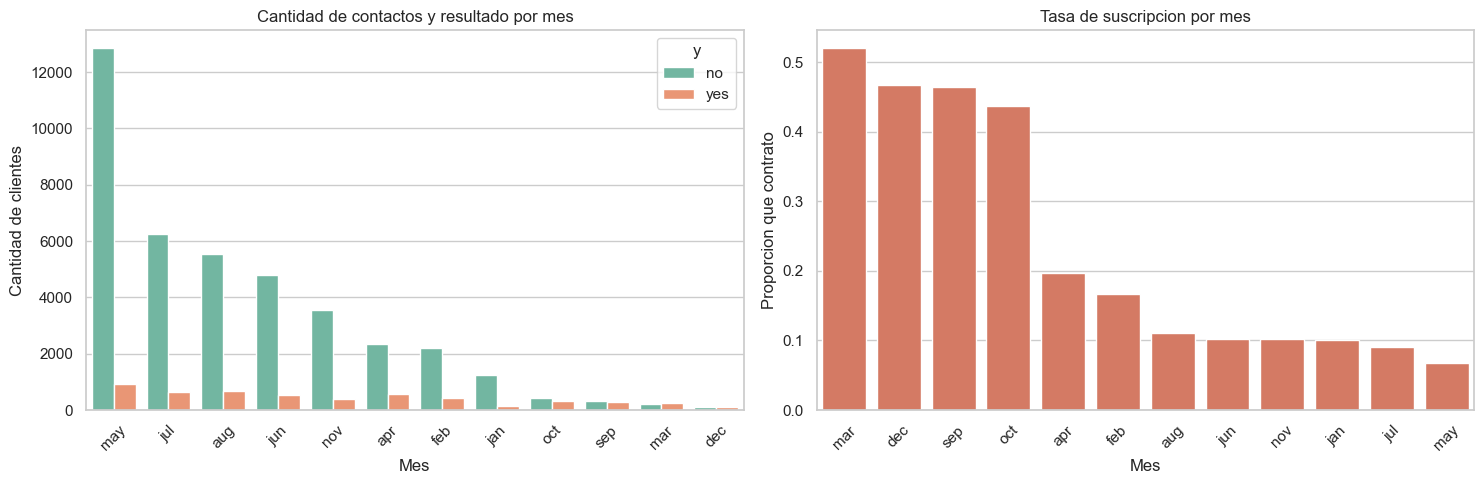

,tasa_suscripcion
poutcome,
success,64.73%
other,16.68%
failure,12.61%
unknown,9.16%


In [5]:
print('Registros duplicados:', df.duplicated().sum())
missing_summary = df.isna().sum().rename('faltantes').to_frame()
unknown_summary = (df.select_dtypes(include='object') == 'unknown').sum().sort_values(ascending=False).rename('categoria_unknown').to_frame()
quality_summary = missing_summary.join(unknown_summary, how='outer').fillna(0).astype(int)
display(quality_summary)

class_summary = df.groupby('y').size().rename('clientes').to_frame()
class_summary['proporcion'] = class_summary['clientes'] / len(df)
display(class_summary.style.format({'proporcion': '{:.2%}'}))

numeric_eda = df[numeric_predictors + ['y']].groupby('y').agg(['mean', 'median']).T.round(2)
display(numeric_eda)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='month', hue='y', order=df['month'].value_counts().index, ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de contactos y resultado por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=45)
month_rate = df.groupby('month', observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[1], color='#e76f51')
axes[1].set_title('Tasa de suscripcion por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Proporcion que contrato')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

poutcome_rate = df.groupby('poutcome', observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
display(poutcome_rate.rename('tasa_suscripcion').to_frame().style.format({'tasa_suscripcion': '{:.2%}'}))

### Hallazgos de los gráficos

- **Contactos y resultados por mes:** mayo concentra el mayor volumen de llamadas, pero no la mayor tasa de contratación. Meses con menos contactos, como marzo, septiembre, octubre y diciembre, exhiben tasas proporcionalmente superiores; por eso volumen y efectividad deben analizarse por separado.
- **Lectura operativa:** el patrón mensual puede reflejar estacionalidad y también diferencias en el tipo de clientes contactados. No basta para concluir que cambiar el mes de contacto causará una mayor contratación.

## 3. Preparacion y modelos

Se eliminan `duration` y `contact` del modelado: `duration` solo se conoce despues de realizar la llamada y produciria fuga de informacion para una prediccion operativa. Las variables categoricas se imputan y codifican con one-hot; las numericas se imputan y estandarizan dentro del pipeline.

In [6]:
X = df.drop(columns='y').copy()
y = df['y'].map({'no': 0, 'yes': 1})
X = X.drop(columns=['duration', 'contact'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_features), ('cat', categorical_pipe, categorical_features)])
models = {
    'Regresion logistica': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
}

## 4. Resultados obtenidos

Se entrenan tres modelos y se comparan mediante accuracy, precision, recall, F1 y ROC-AUC.

In [7]:
results = []
fitted_models = {}
for name, estimator in models.items():
    model = Pipeline([('prep', preprocessor), ('model', estimator)])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    fitted_models[name] = model
    results.append({'Modelo': name, 'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred), 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, proba)})
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
display(results_df.style.format({c:'{:.3f}' for c in results_df.columns if c != 'Modelo'}))

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.885,0.513,0.383,0.439,0.787
0,Regresion logistica,0.762,0.269,0.599,0.371,0.752
2,Gradient Boosting,0.894,0.657,0.201,0.308,0.784


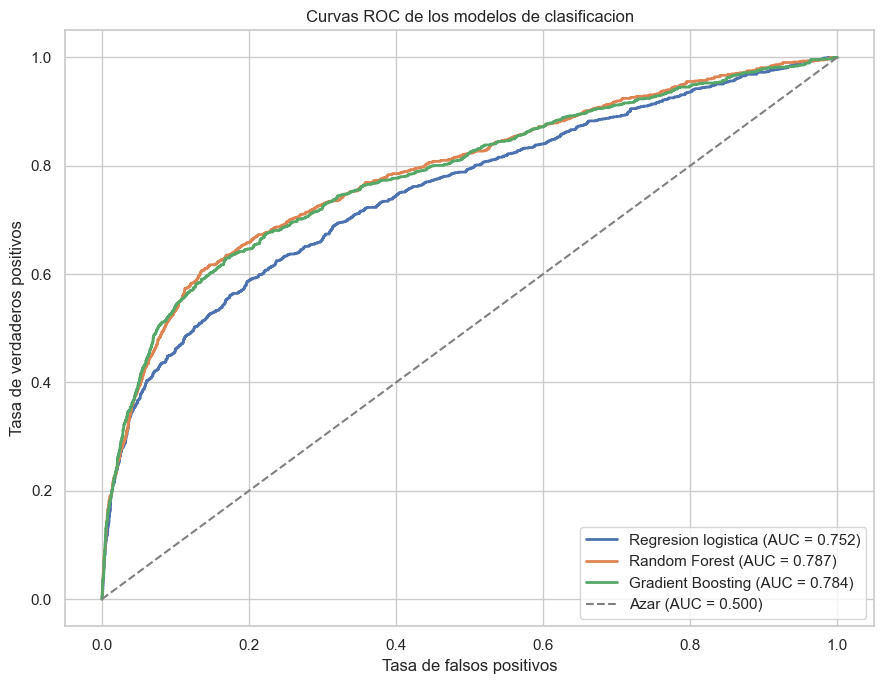

In [8]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))
for name, model in fitted_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2, label=f'{name} (AUC = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC = 0.500)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC de los modelos de clasificacion')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Hallazgo del gráfico

Las tres curvas quedan por encima de la diagonal de azar, por lo que todos los modelos tienen capacidad de ordenamiento. Random Forest obtiene el ROC-AUC de prueba más alto (0,787), muy cerca de Gradient Boosting (0,784), mientras que la regresión logística alcanza 0,752. La cercanía entre los dos primeros aconseja considerar también el umbral y el costo de cada tipo de error.

,Modelo,Precision
0,Gradient Boosting,0.657
1,Random Forest,0.513
2,Regresion logistica,0.269


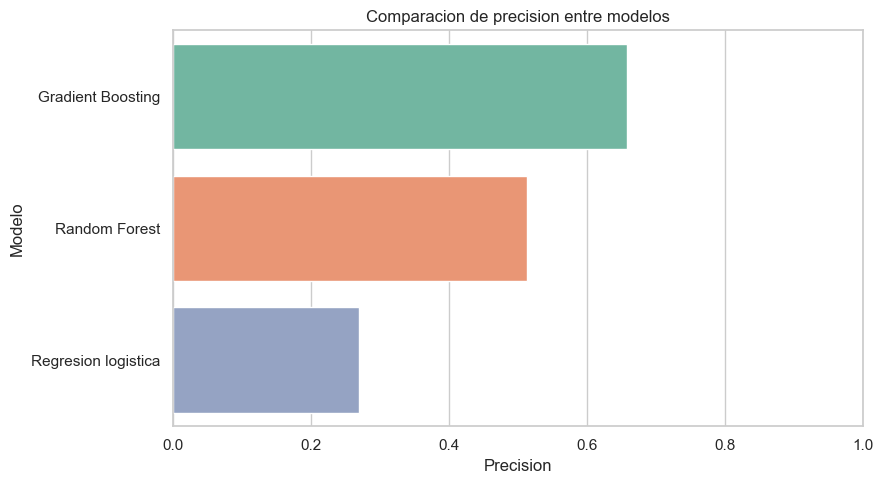

In [9]:
precision_comparison = results_df[['Modelo', 'Precision']].sort_values('Precision', ascending=False).reset_index(drop=True)
display(precision_comparison.style.format({'Precision': '{:.3f}'}))

plt.figure(figsize=(9, 5))
sns.barplot(data=precision_comparison, x='Precision', y='Modelo', hue='Modelo', legend=False, palette='Set2')
plt.xlim(0, 1)
plt.title('Comparacion de precision entre modelos')
plt.xlabel('Precision')
plt.ylabel('Modelo')
plt.tight_layout()
plt.show()

### Hallazgo del gráfico

Gradient Boosting logra la mayor precisión (0,657): aproximadamente dos de cada tres clientes señalados como positivos efectivamente contrataron. Sin embargo, su recall es bajo (0,201), por lo que deja sin detectar a muchos suscriptores. Random Forest ofrece un equilibrio más favorable y consigue el mejor F1 (0,439).

### Tabla consolidada de métricas

La siguiente tabla presenta todas las métricas en formato vertical para facilitar la lectura y la comparación entre modelos.

In [10]:
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
metrics_vertical = results_df[['Modelo'] + metric_columns].melt(
    id_vars='Modelo',
    value_vars=metric_columns,
    var_name='Metrica',
    value_name='Valor'
)
metrics_vertical['Metrica'] = pd.Categorical(metrics_vertical['Metrica'], categories=metric_columns, ordered=True)
metrics_vertical = metrics_vertical.sort_values(['Modelo', 'Metrica']).reset_index(drop=True)
display(metrics_vertical.style.format({'Valor': '{:.3f}'}))

,Modelo,Metrica,Valor
0,Gradient Boosting,Accuracy,0.894
1,Gradient Boosting,Precision,0.657
2,Gradient Boosting,Recall,0.201
3,Gradient Boosting,F1,0.308
4,Gradient Boosting,ROC-AUC,0.784
5,Random Forest,Accuracy,0.885
6,Random Forest,Precision,0.513
7,Random Forest,Recall,0.383
8,Random Forest,F1,0.439
9,Random Forest,ROC-AUC,0.787


### Comparacion de precision

La precision responde: de todos los clientes que el modelo identifica como potenciales suscriptores, ¿cuántos efectivamente contrataron? Un valor mayor implica menos contactos que no terminan en contratación, aunque siempre debe analizarse junto con recall y F1.

,Modelo,ROC-AUC CV promedio,Desvio CV
1,Random Forest,0.777,0.008
2,Gradient Boosting,0.777,0.007
0,Regresion logistica,0.748,0.007


Modelo seleccionado por F1: Random Forest
              precision    recall  f1-score   support

          No       0.92      0.95      0.94      7985
          Si       0.51      0.38      0.44      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.67      0.69      9043
weighted avg       0.87      0.89      0.88      9043



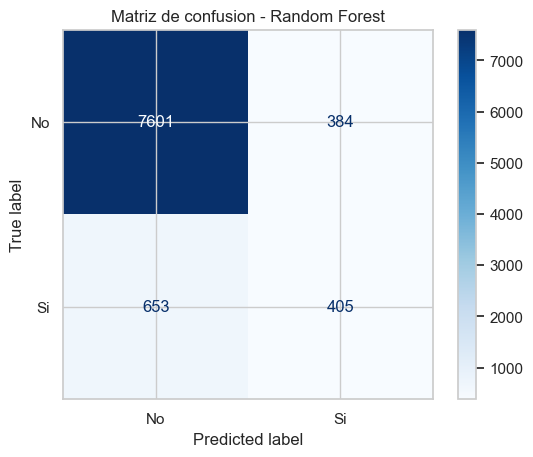

In [11]:
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in fitted_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'Modelo': name, 'ROC-AUC CV promedio': scores.mean(), 'Desvio CV': scores.std()})
display(pd.DataFrame(cv_rows).sort_values('ROC-AUC CV promedio', ascending=False).style.format({'ROC-AUC CV promedio':'{:.3f}', 'Desvio CV':'{:.3f}'}))

best_name = results_df.iloc[0]['Modelo']
best_pred = fitted_models[best_name].predict(X_test)
print(f'Modelo seleccionado por F1: {best_name}')
print(classification_report(y_test, best_pred, target_names=['No', 'Si']))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['No', 'Si'], cmap='Blues')
plt.title(f'Matriz de confusion - {best_name}')
plt.show()

## 4.1. Comparación de modelos con SMOTE — CV=7

SMOTE crea ejemplos sintéticos de la clase minoritaria mediante interpolación entre vecinos. Se utiliza `imblearn.Pipeline` para ajustar el preprocesamiento y aplicar SMOTE solamente sobre el entrenamiento de cada fold. Las versiones con SMOTE no usan `class_weight='balanced'`, evitando compensar dos veces el desbalance.

,Modelo,ROC-AUC,F1,Precision,Recall,Balanced accuracy,Desvio F1
0,Random Forest - Base,0.777,0.439,0.504,0.389,0.669,0.015
1,Gradient Boosting + SMOTE,0.756,0.419,0.484,0.370,0.659,0.013
2,Random Forest + SMOTE,0.767,0.405,0.501,0.340,0.648,0.019
3,Regresion logistica - Base,0.748,0.371,0.270,0.593,0.690,0.005
4,Regresion logistica + SMOTE,0.744,0.364,0.263,0.590,0.686,0.005
5,Gradient Boosting - Base,0.777,0.311,0.639,0.205,0.595,0.020


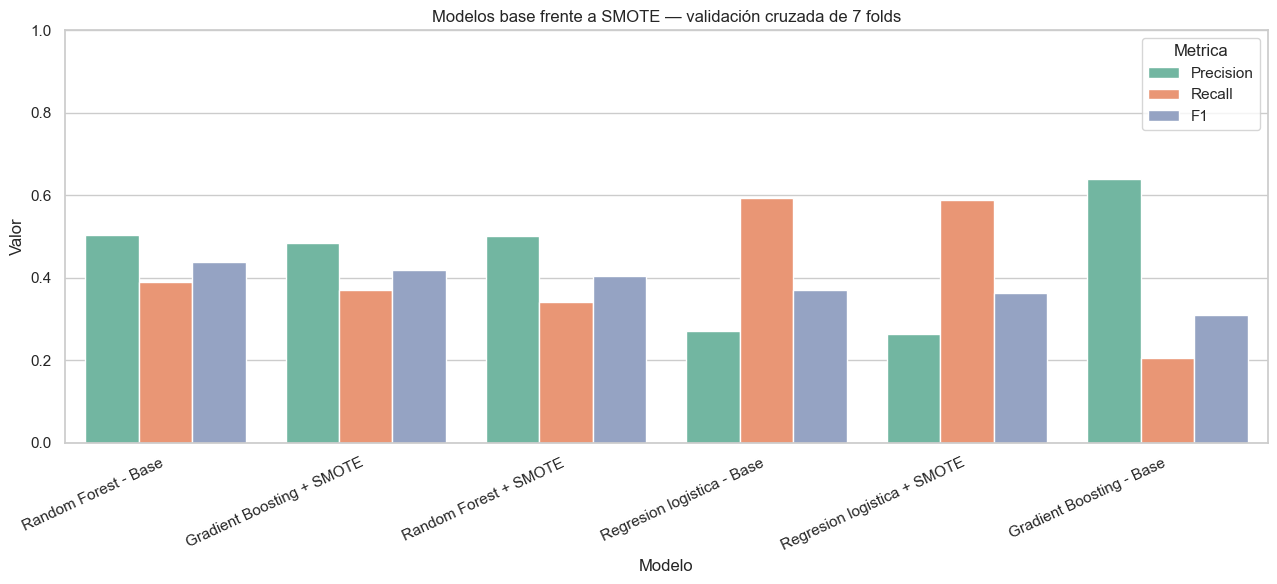

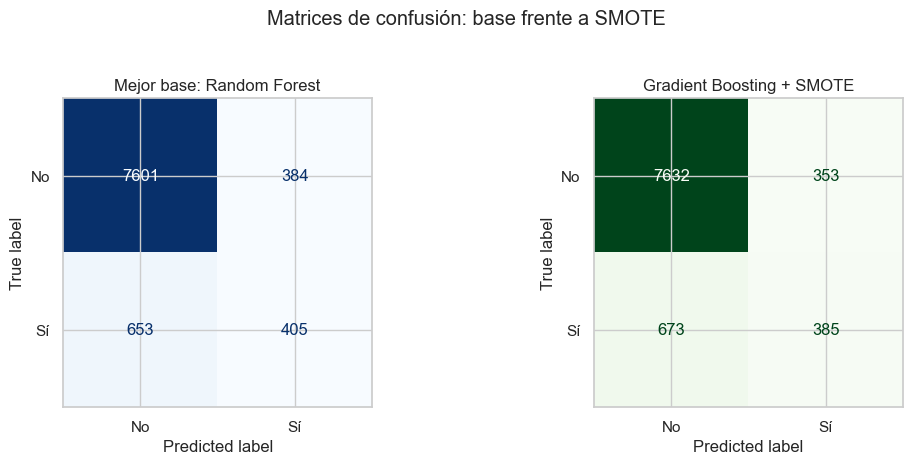

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.model_selection import cross_validate

cv7 = StratifiedKFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
scoring = {'ROC-AUC': 'roc_auc', 'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall', 'Balanced accuracy': 'balanced_accuracy'}

comparison_models = {f'{name} - Base': model for name, model in fitted_models.items()}
smote_estimators = {
    'Regresion logistica + SMOTE': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest + SMOTE': RandomForestClassifier(n_estimators=250, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting + SMOTE': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
}
smote_models = {}
for name, estimator in smote_estimators.items():
    smote_models[name] = ImbPipeline([
        ('prep', clone(preprocessor)),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', estimator)
    ])
comparison_models.update(smote_models)

cv7_rows = []
for name, model in comparison_models.items():
    scores = cross_validate(model, X, y, cv=cv7, scoring=scoring, n_jobs=-1)
    cv7_rows.append({
        'Modelo': name,
        **{metric: scores[f'test_{metric}'].mean() for metric in scoring},
        'Desvio F1': scores['test_F1'].std()
    })
smote_comparison = pd.DataFrame(cv7_rows).sort_values('F1', ascending=False).reset_index(drop=True)
display(smote_comparison.style.format({column: '{:.3f}' for column in smote_comparison.columns if column != 'Modelo'}))

plot_data = smote_comparison.melt(id_vars='Modelo', value_vars=['Precision', 'Recall', 'F1'], var_name='Metrica', value_name='Valor')
plt.figure(figsize=(13, 6))
sns.barplot(data=plot_data, x='Modelo', y='Valor', hue='Metrica', palette='Set2')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.title('Modelos base frente a SMOTE — validación cruzada de 7 folds')
plt.tight_layout()
plt.show()

for name, model in smote_models.items():
    model.fit(X_train, y_train)
best_smote_name = smote_comparison.loc[smote_comparison['Modelo'].str.contains('SMOTE'), 'Modelo'].iloc[0]
best_smote_pred = smote_models[best_smote_name].predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['No', 'Sí'], cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title(f'Mejor base: {best_name}')
ConfusionMatrixDisplay.from_predictions(y_test, best_smote_pred, display_labels=['No', 'Sí'], cmap='Greens', colorbar=False, ax=axes[1])
axes[1].set_title(best_smote_name)
plt.suptitle('Matrices de confusión: base frente a SMOTE', y=1.03)
plt.tight_layout()
plt.show()

### Hallazgo de SMOTE

SMOTE mejora especialmente a Gradient Boosting: aumenta su capacidad de detectar la clase “Sí” y eleva su F1, aunque reduce la precisión porque genera más falsos positivos. En la comparación ejecutada con los mismos 7 folds, Random Forest base conserva el mayor F1 promedio. Por tanto, SMOTE queda documentado como una alternativa útil frente al desbalance, pero no se selecciona automáticamente como modelo final.

La conclusión para stakeholders es un intercambio operativo: con SMOTE pueden encontrarse más clientes interesados, pero también aumenta la cantidad de contactos que no terminan en contratación.

## 4.2. Pruebas estadísticas, matrices e interpretabilidad

Para respaldar la selección se agregan pruebas que utilizan los mismos datos y particiones: Friedman compara el ROC-AUC de los tres modelos base en los 7 folds; McNemar compara sus errores sobre los mismos clientes de prueba. También se presentan las tres matrices de confusión y una importancia por permutación con variables originales.

,ROC_AUC_promedio,ROC_AUC_desvio,F1_promedio,Precision_promedio,Recall_promedio,Balanced_accuracy
Modelo,,,,,,
Random Forest,0.777,0.008,0.439,0.504,0.389,0.669
Regresion logistica,0.748,0.008,0.371,0.270,0.593,0.690
Gradient Boosting,0.777,0.007,0.311,0.639,0.205,0.595


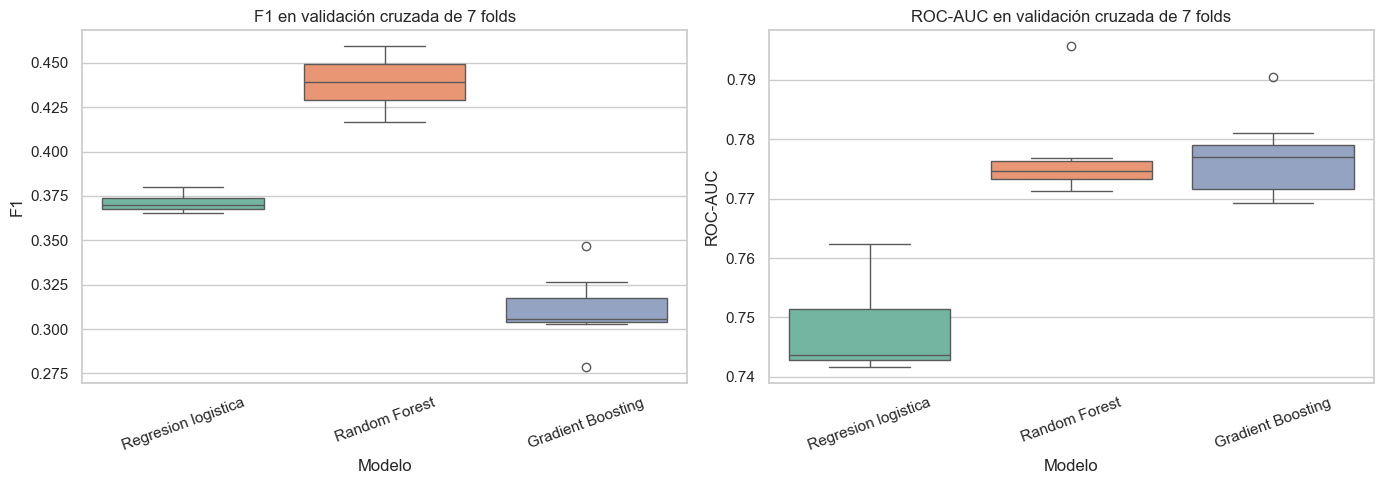

Friedman para ROC-AUC: estadístico=10.571, p=0.005063


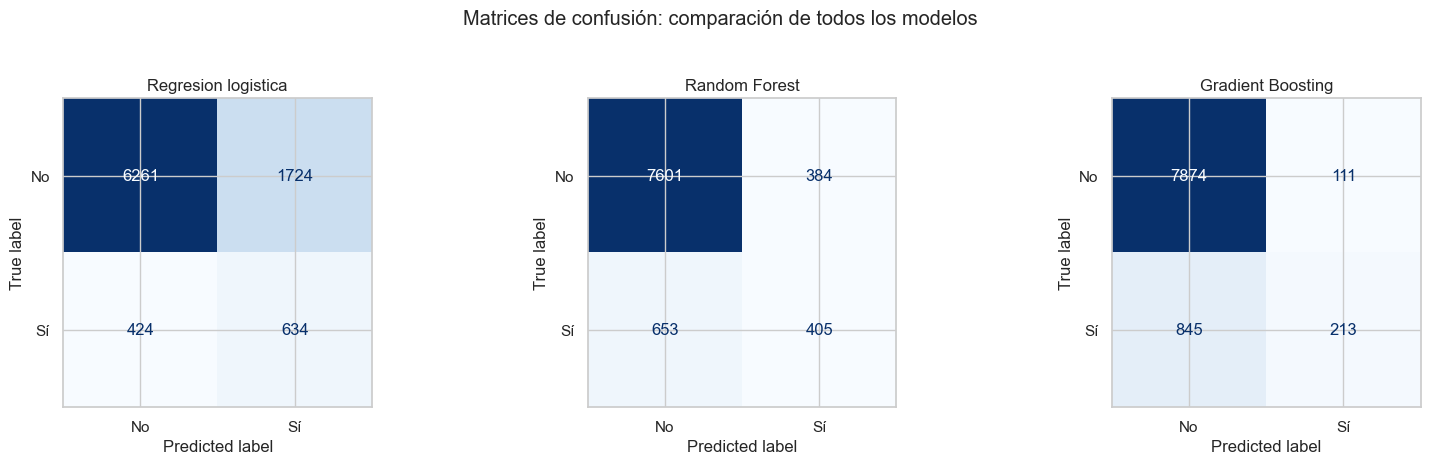

McNemar exacta Random Forest vs Regresion logistica: desacuerdos=(1378, 267), p=2.851e-180
McNemar exacta Random Forest vs Gradient Boosting: desacuerdos=(201, 282), p=0.0002644


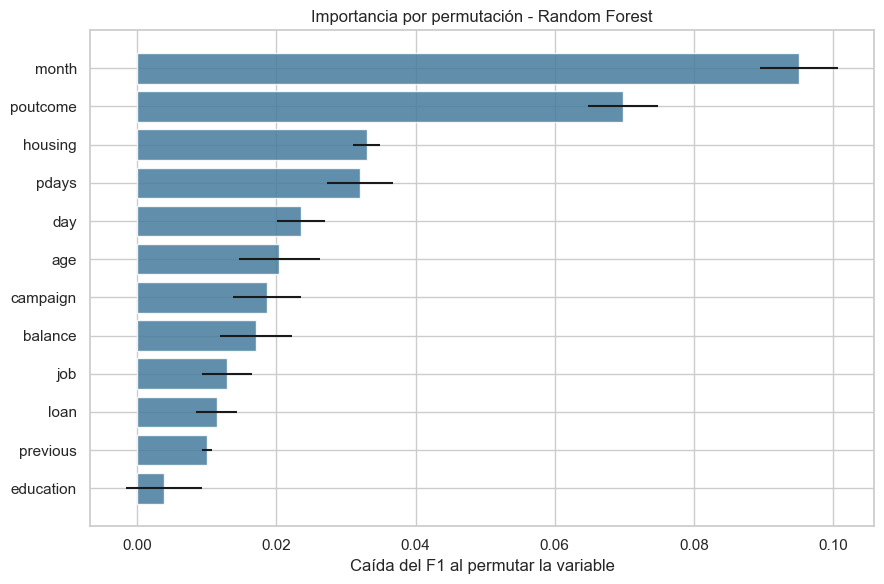

In [13]:
from scipy.stats import friedmanchisquare, binomtest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate

base_cv_rows = []
for name, model in fitted_models.items():
    scores = cross_validate(
        model, X, y, cv=cv7,
        scoring={'ROC-AUC': 'roc_auc', 'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall', 'Balanced accuracy': 'balanced_accuracy'},
        n_jobs=-1
    )
    for fold in range(cv7.get_n_splits()):
        base_cv_rows.append({
            'Modelo': name, 'Fold': fold + 1,
            'ROC-AUC': scores['test_ROC-AUC'][fold], 'F1': scores['test_F1'][fold],
            'Precision': scores['test_Precision'][fold], 'Recall': scores['test_Recall'][fold],
            'Balanced accuracy': scores['test_Balanced accuracy'][fold]
        })
base_cv_detail = pd.DataFrame(base_cv_rows)
base_cv_summary = base_cv_detail.groupby('Modelo').agg(
    ROC_AUC_promedio=('ROC-AUC', 'mean'), ROC_AUC_desvio=('ROC-AUC', 'std'),
    F1_promedio=('F1', 'mean'), Precision_promedio=('Precision', 'mean'),
    Recall_promedio=('Recall', 'mean'), Balanced_accuracy=('Balanced accuracy', 'mean')
).sort_values('F1_promedio', ascending=False)
display(base_cv_summary.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=base_cv_detail, x='Modelo', y='F1', hue='Modelo', legend=False, palette='Set2', ax=axes[0])
axes[0].set_title('F1 en validación cruzada de 7 folds')
axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=base_cv_detail, x='Modelo', y='ROC-AUC', hue='Modelo', legend=False, palette='Set2', ax=axes[1])
axes[1].set_title('ROC-AUC en validación cruzada de 7 folds')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

wide_auc = base_cv_detail.pivot(index='Fold', columns='Modelo', values='ROC-AUC')
friedman_stat, friedman_p = friedmanchisquare(*[wide_auc[column] for column in wide_auc.columns])
print(f'Friedman para ROC-AUC: estadístico={friedman_stat:.3f}, p={friedman_p:.4g}')

test_predictions = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    prediction = model.predict(X_test)
    test_predictions[name] = prediction
    ConfusionMatrixDisplay.from_predictions(y_test, prediction, display_labels=['No', 'Sí'], cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(name)
plt.suptitle('Matrices de confusión: comparación de todos los modelos', y=1.03)
plt.tight_layout()
plt.show()

selected_name = base_cv_summary.index[0]
selected_correct = test_predictions[selected_name] == y_test.to_numpy()
for other_name in [name for name in fitted_models if name != selected_name]:
    other_correct = test_predictions[other_name] == y_test.to_numpy()
    selected_only = int(np.sum(selected_correct & ~other_correct))
    other_only = int(np.sum(~selected_correct & other_correct))
    mcnemar_p = binomtest(min(selected_only, other_only), selected_only + other_only, p=0.5).pvalue
    print(f'McNemar exacta {selected_name} vs {other_name}: desacuerdos=({selected_only}, {other_only}), p={mcnemar_p:.4g}')

selected_model = fitted_models[selected_name]
perm = permutation_importance(selected_model, X_test, y_test, scoring='f1', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
importance_df = pd.DataFrame({'Variable': X.columns, 'Caida_F1': perm.importances_mean, 'Desvio': perm.importances_std}).sort_values('Caida_F1').tail(12)
plt.figure(figsize=(9, 6))
plt.barh(importance_df['Variable'], importance_df['Caida_F1'], xerr=importance_df['Desvio'], color='#457b9d', alpha=0.85)
plt.xlabel('Caída del F1 al permutar la variable')
plt.title(f'Importancia por permutación - {selected_name}')
plt.tight_layout()
plt.show()

### Interpretación de las pruebas adicionales

- Friedman permite determinar si las diferencias de ROC-AUC se mantienen a través de los 7 folds y no dependen de una única partición.
- McNemar analiza si dos modelos se equivocan de manera diferente sobre los mismos clientes. Una diferencia significativa no implica automáticamente que uno sea mejor para el negocio; debe leerse junto con precision, recall y F1.
- Las matrices muestran el costo concreto de cada alternativa: falsos positivos equivalen a contactos potencialmente improductivos y falsos negativos a oportunidades que no se priorizan.
- La importancia por permutación indica cuánto cae el F1 al desordenar cada variable. Facilita la explicación a stakeholders usando variables originales, aunque no demuestra causalidad.

Random Forest se mantiene como modelo principal si conserva el mayor F1 promedio en CV=7. Gradient Boosting favorece precisión; regresión logística favorece recall. SMOTE se considera una estrategia adicional y se selecciona solamente si mejora el equilibrio requerido por el negocio.

### Hallazgos de la evaluación final

- **Matriz de confusión:** Random Forest fue seleccionado por F1. Reconoce correctamente la mayoría de los “No”, pero detecta solo 402 de los 1.058 clientes que contrataron aproximadamente; su recall para “Sí” es 0,383. Esto muestra que aún hay bastantes falsos negativos.
- **Decisión de negocio:** si perder un cliente interesado es más costoso que hacer una llamada adicional, convendría reducir el umbral de clasificación y aceptar más falsos positivos. Si se prioriza evitar contactos improductivos, Gradient Boosting ofrece mayor precisión.

## 5. Interpretacion de resultados

La matriz de confusion, las curvas ROC y la tabla consolidada permiten comparar los aciertos y errores de los modelos.

## 6. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del modelado

El modelo recibe informacion disponible sobre un cliente y devuelve una decision: **si** o **no**, donde “si” significa que probablemente contratara el deposito a plazo. El objetivo practico es ayudar a priorizar contactos, no reemplazar la decision del cliente.

### Criterio para seleccionar los algoritmos

Se comparan tres enfoques complementarios. La regresion logistica ofrece una referencia sencilla y probabilistica. Random Forest permite capturar reglas y combinaciones entre variables. Gradient Boosting agrega arboles de forma progresiva para corregir errores. Compararlos permite evaluar si los modelos mas complejos aportan una mejora real frente a una alternativa interpretable.

**Regresion logistica.** Aunque su nombre incluye “regresion”, aqui se usa para clasificar. Calcula una probabilidad de suscripcion y la convierte en “si” o “no” usando un umbral. Es una buena referencia porque es rapida y relativamente facil de interpretar.

**Random Forest.** Combina muchos arboles de decision. Cada arbol analiza reglas diferentes sobre edad, empleo, saldo, historial y campaña; la respuesta final surge de combinar esas decisiones. Puede detectar combinaciones de variables que una regla simple no captura.

**Gradient Boosting.** Genera arboles uno despues de otro. Cada nuevo arbol presta atencion a los clientes que fueron clasificados incorrectamente antes. Puede lograr buen desempeño, aunque sus decisiones son mas dificiles de resumir en una sola regla.

### Criterios de evaluacion

- **Accuracy:** porcentaje total de aciertos. Puede ser engañosa cuando hay muchos mas “no” que “si”.
- **Precision:** de los clientes que el modelo marco como posibles interesados, cuantos realmente contrataron.
- **Recall:** de todos los clientes que realmente contrataron, cuantos fueron encontrados por el modelo.
- **F1:** combina precision y recall en un unico valor. Es util cuando ambas cosas importan.
- **ROC-AUC:** mide que tan bien ordena el modelo a los clientes mas propensos antes de elegir un punto de corte. Un valor de 0,5 equivale aproximadamente al azar y un valor mayor indica mejor separacion.

### Interpretacion de resultados

La matriz separa aciertos y errores. Un **falso positivo** es contactar a alguien que finalmente no contrata; un **falso negativo** es no priorizar a alguien que si habria contratado. La importancia de cada error depende del costo de la campaña y de la capacidad del equipo comercial.

Se excluye `duration` porque solo se conoce despues de la llamada. Usarla haria que el modelo pareciera mejor de lo que seria en una campaña real: estaria usando informacion del futuro.

**Decision final:** no siempre conviene elegir el modelo con mayor accuracy. La seleccion debe considerar F1, ROC-AUC, precision, recall y el costo real de los falsos positivos y falsos negativos.